<a href="https://colab.research.google.com/github/RuiXuePitt/CGSimFinetune/blob/main/ColabNB/CGsimFinetune.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#INSTALL NECESSARY PACKAGE

In [ ]:
pip install -U bitsandbytes>=0.46.1

#LOGIN

In [ ]:
import torch
print("torch:", torch.__version__)
print("cuda:", torch.version.cuda)
print("available:", torch.cuda.is_available())
print("count:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("dev0:", torch.cuda.get_device_name(0))

torch: 2.10.0+cu128
cuda: 12.8
available: True
count: 1
dev0: NVIDIA L4


In [ ]:
from google.colab import userdata
from huggingface_hub import login
from datasets import load_dataset
from pathlib import Path
from google.colab import output

output.enable_custom_widget_manager()
login(userdata.get('HugFace'))
curr_path = Path.cwd()

# IMPORTS

In [ ]:
import torch
from transformers import (
    AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig,
    TrainingArguments, Trainer, DataCollatorForSeq2Seq)

In [ ]:
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

In [ ]:
import json
train_data = []
with open("drive/MyDrive/resources/CGSim_Train/traindata.jsonl", "r") as f:
  for line in f:
    train_data.append(json.loads(line))

In [ ]:
from datasets import Dataset

#TOKENIZE AND MASK TOOLS

In [ ]:
IGNORE_INDEX = -100

def _find_all_subseq(haystack, needle):
    """return list of start indices where needle occurs in haystack"""
    if not needle:
        return []
    out = []
    n = len(needle)
    for i in range(len(haystack) - n + 1):
        if haystack[i:i+n] == needle:
            out.append(i)
    return out

def build_labels_by_special_tags(input_ids, tokenizer):
    """
    Unmask tokens inside each assistant block:
      <|start_header_id|>assistant<|end_header_id|> ... <|eot_id|>
    Mask everything else, incl. TOOL_RESPONSE blocks.
    """
    labels = [IGNORE_INDEX] * len(input_ids)

    # these must be actual special tokens in tokenizer
    a_start = tokenizer.encode("<|start_header_id|>assistant<|end_header_id|>", add_special_tokens=False)
    eot     = tokenizer.encode("<|eot_id|>", add_special_tokens=False)

    # optional: mask TOOL_RESPONSE blocks even if they appear inside (usually they don't)
    tr_start = tokenizer.encode("<TOOL_RESPONSE>", add_special_tokens=False)
    tr_end   = tokenizer.encode("</TOOL_RESPONSE>", add_special_tokens=False)

    # find assistant block starts
    a_starts = _find_all_subseq(input_ids, a_start)

    for s in a_starts:
        # content begins right after the assistant header tokens
        content_start = s + len(a_start)

        # find the next eot after content_start
        eots = [i for i in _find_all_subseq(input_ids[content_start:], eot)]
        if not eots:
            continue
        eot_pos = content_start + eots[0]  # index where <|eot_id|> begins

        # AFTER: include the eot tokens
        eot_end = min(eot_pos + len(eot), len(input_ids))
        for i in range(content_start, eot_end):
            labels[i] = input_ids[i]

    # mask TOOL_RESPONSE blocks (safety, in your template they are in user blocks anyway)
    trs = _find_all_subseq(input_ids, tr_start)
    for s in trs:
        ends = _find_all_subseq(input_ids[s+len(tr_start):], tr_end)
        if not ends:
            continue
        e = s + len(tr_start) + ends[0] + len(tr_end)
        for i in range(s, e):
            labels[i] = IGNORE_INDEX

    return labels

def tokenize_and_mask(example, tokenizer, max_length=5120):
    text = tokenizer.apply_chat_template(
        example["messages"],
        tools=example.get("tools"),
        tokenize=False,
        add_generation_prompt=False,
    )
    enc = tokenizer(text, truncation=True, max_length=max_length, add_special_tokens=False)
    input_ids = enc["input_ids"]
    labels = build_labels_by_special_tags(input_ids, tokenizer)
    return {"input_ids": input_ids, "attention_mask": enc["attention_mask"], "labels": labels}

# SETTINGS

###1. Tokenizer

In [ ]:
repo_id = "AI4SciNoob/Llama-3.1-Nemotron-Nano-8B-v1-AskCGSim"
tokenizer = AutoTokenizer.from_pretrained(repo_id)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/933 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.6k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

In [ ]:
if tokenizer.pad_token is None:
  print("Setting pad token as ", tokenizer.eos_token)
  tokenizer.pad_token = tokenizer.eos_token

Setting pad token as  <|eot_id|>


###2. QLoRA 4bit Config
> [reference](https://huggingface.co/docs/peft/developer_guides/quantization)



In [ ]:
config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
)

###3. Load Model

####(a) Load Quantized Model

In [ ]:
model = AutoModelForCausalLM.from_pretrained(
    repo_id,
    quantization_config=config,
    device_map="auto",
    dtype=torch.bfloat16)
model.config.use_cache = False # turn off caching for training

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/185 [00:00<?, ?B/s]

In [ ]:
model = prepare_model_for_kbit_training(model)
with torch.no_grad():
    model.model.embed_tokens.to(torch.bfloat16)
    model.lm_head.to(torch.bfloat16)

In [ ]:
print("allocated GiB:", torch.cuda.memory_allocated()/1024**3)
print("reserved  GiB:", torch.cuda.memory_reserved()/1024**3)
print("is_loaded_in_4bit:", getattr(model, "is_loaded_in_4bit", None))
print("is_loaded_in_8bit:", getattr(model, "is_loaded_in_8bit", None))
# print(torch.cuda.memory_summary())

allocated GiB: 5.311601638793945
reserved  GiB: 18.783203125
is_loaded_in_4bit: True
is_loaded_in_8bit: None


In [ ]:
def report_big_tensors(model, topk=20):
    items = []
    for name, p in model.named_parameters():
        nbytes = p.numel() * p.element_size()
        items.append((nbytes, str(p.dtype), tuple(p.shape), name))
    items.sort(reverse=True, key=lambda x: x[0])
    for nbytes, dt, shp, name in items[:topk]:
        print(f"{nbytes/1024**2:8.1f} MiB  {dt:10s}  {shp!s:18s}  {name}")

report_big_tensors(model)

  1002.0 MiB  torch.bfloat16  (128256, 4096)      model.embed_tokens.weight
  1002.0 MiB  torch.bfloat16  (128256, 4096)      lm_head.weight
    28.0 MiB  torch.uint8  (29360128, 1)       model.layers.0.mlp.gate_proj.weight
    28.0 MiB  torch.uint8  (29360128, 1)       model.layers.0.mlp.up_proj.weight
    28.0 MiB  torch.uint8  (29360128, 1)       model.layers.0.mlp.down_proj.weight
    28.0 MiB  torch.uint8  (29360128, 1)       model.layers.1.mlp.gate_proj.weight
    28.0 MiB  torch.uint8  (29360128, 1)       model.layers.1.mlp.up_proj.weight
    28.0 MiB  torch.uint8  (29360128, 1)       model.layers.1.mlp.down_proj.weight
    28.0 MiB  torch.uint8  (29360128, 1)       model.layers.2.mlp.gate_proj.weight
    28.0 MiB  torch.uint8  (29360128, 1)       model.layers.2.mlp.up_proj.weight
    28.0 MiB  torch.uint8  (29360128, 1)       model.layers.2.mlp.down_proj.weight
    28.0 MiB  torch.uint8  (29360128, 1)       model.layers.3.mlp.gate_proj.weight
    28.0 MiB  torch.uint8  (2936012

In [ ]:
for name, p in model.named_parameters():
    print(name)

model.embed_tokens.weight
model.layers.0.self_attn.q_proj.weight
model.layers.0.self_attn.k_proj.weight
model.layers.0.self_attn.v_proj.weight
model.layers.0.self_attn.o_proj.weight
model.layers.0.mlp.gate_proj.weight
model.layers.0.mlp.up_proj.weight
model.layers.0.mlp.down_proj.weight
model.layers.0.input_layernorm.weight
model.layers.0.post_attention_layernorm.weight
model.layers.1.self_attn.q_proj.weight
model.layers.1.self_attn.k_proj.weight
model.layers.1.self_attn.v_proj.weight
model.layers.1.self_attn.o_proj.weight
model.layers.1.mlp.gate_proj.weight
model.layers.1.mlp.up_proj.weight
model.layers.1.mlp.down_proj.weight
model.layers.1.input_layernorm.weight
model.layers.1.post_attention_layernorm.weight
model.layers.2.self_attn.q_proj.weight
model.layers.2.self_attn.k_proj.weight
model.layers.2.self_attn.v_proj.weight
model.layers.2.self_attn.o_proj.weight
model.layers.2.mlp.gate_proj.weight
model.layers.2.mlp.up_proj.weight
model.layers.2.mlp.down_proj.weight
model.layers.2.inp

####(b) LoRA Setting

In [ ]:
lora = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"]
)
model = get_peft_model(model, lora)
model.print_trainable_parameters()

trainable params: 13,631,488 || all params: 8,043,892,736 || trainable%: 0.1695


###4. Data Processing

In [ ]:
ds = Dataset.from_list(train_data)
processed_ds = ds.map(lambda x: tokenize_and_mask(x, tokenizer), remove_columns=ds.column_names)

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [ ]:
lens = [len(x["input_ids"]) for x in processed_ds]
print(len(lens))
print(min(lens), max(lens), len(set(lens)))

1000
1349 4454 377


In [ ]:
collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    padding=True,
    return_tensors="pt",
    label_pad_token_id=IGNORE_INDEX,
)

###5. Training Settings

In [ ]:
run_name = "nemotron-llama8b-CGsim"
output_dir = "./drive/MyDrive/" + run_name

batch_size = 4
eval_steps = 50
total_epoch = 1
save_steps = 100

args = TrainingArguments(
  output_dir=output_dir,
  warmup_steps=1,
  per_device_train_batch_size=batch_size,
  gradient_accumulation_steps=1,
  gradient_checkpointing=True,
  num_train_epochs=total_epoch,
  learning_rate=2e-4,
  bf16=True,
  optim="paged_adamw_8bit",
  logging_dir="./drive/MyDrive/logs",        # Directory for storing logs
  save_strategy="steps",       # Save the model checkpoint every logging step
  save_steps=save_steps,                # Save checkpoints every 100 steps
  logging_steps=10,
  per_device_eval_batch_size=batch_size,
  eval_strategy="steps",
  eval_steps=eval_steps,               # Evaluate and save checkpoints every 50 steps
  do_eval=True,                # Perform evaluation at the end of
  report_to="none"
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
splits = processed_ds.train_test_split(test_size=0.1, seed=42)
train_ds = splits["train"]
eval_ds  = splits["test"]

In [ ]:
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=eval_ds,
    data_collator=collator,
)

In [ ]:
'''
Make sure that there are really unmasked (to be learnt) contents
'''
x0 = processed_ds[0]
n_train = sum(1 for t in x0["labels"] if t != IGNORE_INDEX)
print("sanity: tokens contributing to loss =", n_train)
n_total = len(x0["labels"])
n_train = sum(t != IGNORE_INDEX for t in x0["labels"])
print("n_total =", n_total, "n_train =", n_train, "ratio =", n_train / n_total)

sanity: tokens contributing to loss = 197
n_total = 1419 n_train = 197 ratio = 0.13883016208597604


#GO!!!

In [ ]:
out = trainer.train()

Step,Training Loss,Validation Loss
50,0.003707,0.004934
100,0.003503,0.001374
150,0.001805,0.000456
200,0.000558,0.000231
250,0.000155,0.000187


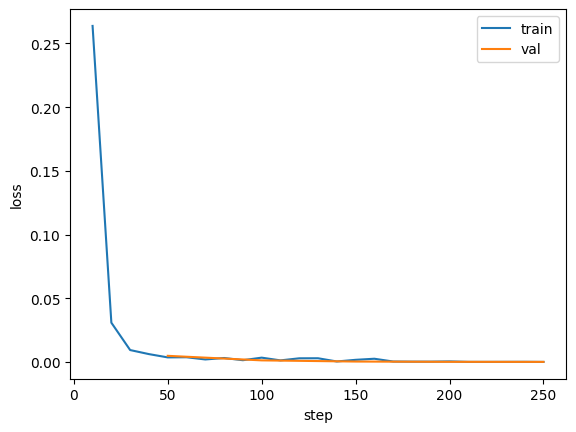

In [ ]:
import matplotlib.pyplot as plt

history = trainer.state.log_history

train_steps, train_loss = [], []
eval_steps, eval_loss = [], []

for h in history:
    if "loss" in h and "step" in h:
        train_steps.append(h["step"])
        train_loss.append(h["loss"])
    if "eval_loss" in h and "step" in h:
        eval_steps.append(h["step"])
        eval_loss.append(h["eval_loss"])

plt.figure()
plt.plot(train_steps, train_loss, label="train")
plt.plot(eval_steps, eval_loss, label="val")
plt.xlabel("step")
plt.ylabel("loss")
plt.legend()
plt.show()

#TEST

### 1. QUICK TEST


In [ ]:
print(type(model), type(tokenizer))

<class 'peft.peft_model.PeftModelForCausalLM'> <class 'transformers.tokenization_utils_tokenizers.TokenizersBackend'>


In [ ]:
question = "What is the allocation job id at site AGLT2_site_12?"

messages = [
    {"role": "system", "content": "You are a CGsim agent. Use tools when needed."},
    {"role": "user", "content": question},
]

prompt = tokenizer.apply_chat_template(
    messages,
    tools=train_data[0]["tools"],
    tokenize=False,
    add_generation_prompt=True,
)

inputs = tokenizer(prompt, return_tensors="pt", add_special_tokens=False).to(model.device)

tokenizer.pad_token = tokenizer.eos_token
model.config.pad_token_id = tokenizer.eos_token_id
model.config.use_cache = True   # only for inferencing

with torch.no_grad():
    out = model.generate(
        **inputs,
        max_new_tokens=256,
        do_sample=False
    )

gen1 = tokenizer.decode(out[0], skip_special_tokens=False)
print(gen1)

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


<|begin_of_text|><|start_header_id|>system<|end_header_id|>

You are a CGsim agent. Use tools when needed.

<AVAILABLE_TOOLS>[{"name": "check_JobAllocation", "description": "Sample JobAllocation events from the CGsim `EVENTS` table to inspect the job allocation data structure (columns and example rows).", "parameters": {"type": "object", "properties": {}, "required": [], "additionalProperties": false}}, {"name": "check_FileTransfer", "description": "Sample FileTransfer events from the CGsim `EVENTS` table to inspect the file transfer data structure (columns and example rows).", "parameters": {"type": "object", "properties": {}, "required": [], "additionalProperties": false}}, {"name": "check_FileRead", "description": "Sample FileRead events from the CGsim `EVENTS` table to inspect the file read data structure (columns and example rows).", "parameters": {"type": "object", "properties": {}, "required": [], "additionalProperties": false}}, {"name": "check_FileWrite", "description": "Sampl

In [ ]:
messages = [
{'role': 'system',
  'content': 'You are a CGsim agent. Answer questions related to grid simulation related questions. Use tools when needed.'},
 {'role': 'user',
  'content': 'What is the allocation job id at site AGLT2_site_12?'},
 {'role': 'assistant',
  'content': "Let's think step by step.\nAccording to 'allocation', JobAllocation data structure should be checked.\n",
  'tool_calls': [{'type': 'function',
    'function': {'name': 'check_JobAllocation', 'arguments': {}}}]},
 {'role': 'tool',
  'content': '{"Field": "JobAllocation", "Columns": ["_ID", "EVENT", "STATE", "STATUS", "JOB_ID", "TIME", "METADATA"], "Example": [[24, "JobAllocation", "Finished", "assigned", "2765833703", 0.0, {"grid_cpu_util": 1.1714749367330317e-09, "grid_storage_util": 0.07677378145373592, "host": "AGLT2_site_15_cpu-0", "site": "AGLT2_site_15", "site_cpu_util": 0.00014540960066888417, "site_storage_util": 0.07677378145373592}], [36, "JobAllocation", "Finished", "assigned", "8859535416", 0.0, {"grid_cpu_util": 1.1714749367330317e-09, "grid_storage_util": 0.07677378145373592, "host": "AGLT2_site_10_cpu-0", "site": "AGLT2_site_10", "site_cpu_util": 0.00020962712575007205, "site_storage_util": 0.07677378145373592}], [23, "JobAllocation", "Finished", "assigned", "1650119556", 0.0, {"grid_cpu_util": 1.1714749367330317e-09, "grid_storage_util": 0.07677378145373592, "host": "AGLT2_site_19_cpu-0", "site": "AGLT2_site_19", "site_cpu_util": 0.00013454875710585624, "site_storage_util": 0.07677378145373592}], [1, "JobAllocation", "Finished", "assigned", "1202004839", 0.0, {"grid_cpu_util": 5.857374683665159e-11, "grid_storage_util": 0.07677378145373592, "host": "AGLT2_site_18_cpu-0", "site": "AGLT2_site_18", "site_cpu_util": 0.0001287519111611813, "site_storage_util": 0.07677378145373592}], [22, "JobAllocation", "Finished", "assigned", "1546838737", 0.0, {"grid_cpu_util": 1.1714749367330317e-09, "grid_storage_util": 0.07677378145373592, "host": "AGLT2_site_9_cpu-0", "site": "AGLT2_site_9", "site_cpu_util": 0.00018029387902280717, "site_storage_util": 0.07677378145373592}]]}'}
             ]
prompt = tokenizer.apply_chat_template(
    messages,
    tools=train_data[0]["tools"],
    tokenize=False,
    add_generation_prompt=True,
)

inputs = tokenizer(prompt, return_tensors="pt", add_special_tokens=False).to(model.device)

tokenizer.pad_token = tokenizer.eos_token
model.config.pad_token_id = tokenizer.eos_token_id
model.config.use_cache = True   # only for inferencing

with torch.no_grad():
    out = model.generate(
        **inputs,
        max_new_tokens=256,
        do_sample=False
    )

gen2 = tokenizer.decode(out[0], skip_special_tokens=False)
print(gen2)


Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


<|begin_of_text|><|start_header_id|>system<|end_header_id|>

You are a CGsim agent. Answer questions related to grid simulation related questions. Use tools when needed.

<AVAILABLE_TOOLS>[{"name": "check_JobAllocation", "description": "Sample JobAllocation events from the CGsim `EVENTS` table to inspect the job allocation data structure (columns and example rows).", "parameters": {"type": "object", "properties": {}, "required": [], "additionalProperties": false}}, {"name": "check_FileTransfer", "description": "Sample FileTransfer events from the CGsim `EVENTS` table to inspect the file transfer data structure (columns and example rows).", "parameters": {"type": "object", "properties": {}, "required": [], "additionalProperties": false}}, {"name": "check_FileRead", "description": "Sample FileRead events from the CGsim `EVENTS` table to inspect the file read data structure (columns and example rows).", "parameters": {"type": "object", "properties": {}, "required": [], "additionalProperti

In [ ]:
messages = [
{'role': 'system',
  'content': 'You are a CGsim agent. Answer questions related to grid simulation related questions. Use tools when needed.'},
 {'role': 'user',
  'content': 'What is the allocation job id at site AGLT2_site_12?'},
 {'role': 'assistant',
  'content': "Let's think step by step.\nAccording to 'allocation', JobAllocation data structure should be checked.\n",
  'tool_calls': [{'type': 'function',
    'function': {'name': 'check_JobAllocation', 'arguments': {}}}]},
 {'role': 'tool',
  'content': '{"Field": "JobAllocation", "Columns": ["_ID", "EVENT", "STATE", "STATUS", "JOB_ID", "TIME", "METADATA"], "Example": [[24, "JobAllocation", "Finished", "assigned", "2765833703", 0.0, {"grid_cpu_util": 1.1714749367330317e-09, "grid_storage_util": 0.07677378145373592, "host": "AGLT2_site_15_cpu-0", "site": "AGLT2_site_15", "site_cpu_util": 0.00014540960066888417, "site_storage_util": 0.07677378145373592}], [36, "JobAllocation", "Finished", "assigned", "8859535416", 0.0, {"grid_cpu_util": 1.1714749367330317e-09, "grid_storage_util": 0.07677378145373592, "host": "AGLT2_site_10_cpu-0", "site": "AGLT2_site_10", "site_cpu_util": 0.00020962712575007205, "site_storage_util": 0.07677378145373592}], [23, "JobAllocation", "Finished", "assigned", "1650119556", 0.0, {"grid_cpu_util": 1.1714749367330317e-09, "grid_storage_util": 0.07677378145373592, "host": "AGLT2_site_19_cpu-0", "site": "AGLT2_site_19", "site_cpu_util": 0.00013454875710585624, "site_storage_util": 0.07677378145373592}], [1, "JobAllocation", "Finished", "assigned", "1202004839", 0.0, {"grid_cpu_util": 5.857374683665159e-11, "grid_storage_util": 0.07677378145373592, "host": "AGLT2_site_18_cpu-0", "site": "AGLT2_site_18", "site_cpu_util": 0.0001287519111611813, "site_storage_util": 0.07677378145373592}], [22, "JobAllocation", "Finished", "assigned", "1546838737", 0.0, {"grid_cpu_util": 1.1714749367330317e-09, "grid_storage_util": 0.07677378145373592, "host": "AGLT2_site_9_cpu-0", "site": "AGLT2_site_9", "site_cpu_util": 0.00018029387902280717, "site_storage_util": 0.07677378145373592}]]}'},
 {'role': 'assistant',
  'content': "Let's think step by step.\nAccording to 'allocation', EVENT = 'JobAllocation' may be used.\nAccording to 'job id', JOB_ID may be selected.\nAccording to 'site', json_extract(METADATA, '$.site') may be used for filtering.\nAccording to 'unique', DISTINCT may be used.\n",
  'tool_calls': [{'type': 'function',
    'function': {'name': 'execute_sql',
     'arguments': {'sql': "SELECT DISTINCT JOB_ID FROM EVENTS WHERE EVENT = 'JobAllocation' AND json_extract(METADATA, '$.site') = 'AGLT2_site_12';"}}}]},
 {'role': 'tool', 'content': '[["2794720992"]]'}]
prompt = tokenizer.apply_chat_template(
    messages,
    tools=train_data[0]["tools"],
    tokenize=False,
    add_generation_prompt=True,
)

inputs = tokenizer(prompt, return_tensors="pt", add_special_tokens=False).to(model.device)

tokenizer.pad_token = tokenizer.eos_token
model.config.pad_token_id = tokenizer.eos_token_id
model.config.use_cache = True   # only for inferencing

with torch.no_grad():
    out = model.generate(
        **inputs,
        max_new_tokens=256,
        do_sample=False
    )

gen3 = tokenizer.decode(out[0], skip_special_tokens=False)
print(gen3)

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


<|begin_of_text|><|start_header_id|>system<|end_header_id|>

You are a CGsim agent. Answer questions related to grid simulation related questions. Use tools when needed.

<AVAILABLE_TOOLS>[{"name": "check_JobAllocation", "description": "Sample JobAllocation events from the CGsim `EVENTS` table to inspect the job allocation data structure (columns and example rows).", "parameters": {"type": "object", "properties": {}, "required": [], "additionalProperties": false}}, {"name": "check_FileTransfer", "description": "Sample FileTransfer events from the CGsim `EVENTS` table to inspect the file transfer data structure (columns and example rows).", "parameters": {"type": "object", "properties": {}, "required": [], "additionalProperties": false}}, {"name": "check_FileRead", "description": "Sample FileRead events from the CGsim `EVENTS` table to inspect the file read data structure (columns and example rows).", "parameters": {"type": "object", "properties": {}, "required": [], "additionalProperti

###2. THOROUGH TEST

In [ ]:
import random

W1, W2, W3 = 0.3, 0.4, 0.3

def get_tool_name(text: str):
    # 取第一个 <TOOLCALL> ... </TOOLCALL> 里的 "name": "xxx"
    s = text.find('<TOOLCALL>')
    if s == -1: return None
    e = text.find('</TOOLCALL>', s)
    if e == -1: return None
    block = text[s:e]

    key = '"name": "'
    i = block.find(key)
    if i == -1: return None
    i += len(key)
    j = block.find('"', i)
    if j == -1: return None
    return block[i:j]


def get_sql(text: str):
    # 找到第一个 "sql": "...."
    key = '"sql": "'
    i = text.find(key)
    if i == -1: return None
    i += len(key)
    j = text.find('"', i)
    if j == -1: return None
    return text[i:j]


def get_ans_value(text: str):
    # 抓 answer 里第一次出现的:  is 'xxxx'
    key = " is '"
    i = text.find(key)
    if i == -1: return None
    i += len(key)
    j = text.find("'", i)
    if j == -1: return None
    return text[i:j]


@torch.no_grad()
def gen(model, tokenizer, messages, tools, max_new_tokens=256):
    prompt = tokenizer.apply_chat_template(
        messages,
        tools=tools,
        tokenize=False,
        add_generation_prompt=True,
    )
    enc = tokenizer(prompt, return_tensors="pt", add_special_tokens=False).to(model.device)
    out = model.generate(**enc, pad_token_id=tokenizer.eos_token_id, max_new_tokens=max_new_tokens, do_sample=False)
    new_ids = out[0][enc["input_ids"].shape[1]:]
    return tokenizer.decode(new_ids, skip_special_tokens=False)

def score_one(model, tokenizer, ex):
    tools = ex["tools"]
    msgs  = ex["messages"]

    # gold（直接从你样本里拿）
    gold_check = msgs[2]["tool_calls"][0]["function"]["name"]         # check_XXX or check_All
    gold_sql   = msgs[4]["tool_calls"][0]["function"]["arguments"]["sql"]
    gold_ans_v = get_ans_value(msgs[-1]["content"])                   # answer里 is 'xxxx' 的 xxxx

    # ===== Part1: system+user -> 预测 check 工具 =====
    gen1 = gen(model, tokenizer, msgs[:2], tools)
    pred_check = get_tool_name(gen1)
    s1 = W1 if (pred_check == gold_check or (pred_check and pred_check.startswith("check_"))) else 0.0

    # ===== Part2: 加上 tool1 response -> 预测 execute_sql + sql =====
    gen2 = gen(model, tokenizer, msgs[:4], tools)
    pred_tool2 = get_tool_name(gen2)
    pred_sql   = get_sql(gen2)
    s2 = W2 if (pred_tool2 == "execute_sql" and pred_sql == gold_sql) else 0.0

    # ===== Part3: 加上 tool2 response -> 预测最终 answer 的 xxxx =====
    gen3 = gen(model, tokenizer, msgs[:6], tools)
    pred_ans_v = get_ans_value(gen3)
    s3 = W3 if (pred_ans_v is not None and pred_ans_v == gold_ans_v) else 0.0

    return (s1+s2+s3), {
        "pred_check": pred_check, "gold_check": gold_check,
        "pred_sql": pred_sql, "gold_sql": gold_sql,
        "pred_ans_v": pred_ans_v, "gold_ans_v": gold_ans_v,
    }

def quick_eval(model, tokenizer, test_data, n=50):
    rows = []
    with open(test_data, "r", encoding="utf-8") as f:
        for i, line in enumerate(f):
            rows.append(json.loads(line))
    rows = random.choices(rows, k=n)

    total = 0.0
    for i, ex in enumerate(rows):
        sc, info = score_one(model, tokenizer, ex)
        total += sc
        print(f"[{i}] score={sc:.2f}  check={info['pred_check']}  sql_ok={info['pred_sql']==info['gold_sql']}  ans={info['pred_ans_v']}")

    print(f"\nAvg score over {len(rows)} = {total/len(rows):.3f}")

In [ ]:
print("use_cache =", model.config.use_cache)
print("device =", next(model.parameters()).device, "dtype =", model.dtype)

use_cache = True
device = cuda:0 dtype = torch.bfloat16


In [ ]:
quick_eval(model, tokenizer, "drive/MyDrive/resources/CGSim_Train/testdata.jsonl", n=50)

[0] score=1.00  check=check_FileRead  sql_ok=True  ans=AGLT2_CALIBDISK
[1] score=1.00  check=check_JobAllocation  sql_ok=True  ans=7047628203
[2] score=1.00  check=check_JobAllocation  sql_ok=True  ans=0.00012016703217472286
[3] score=1.00  check=check_JobAllocation  sql_ok=True  ans=0.07677378145373592
[4] score=1.00  check=check_All  sql_ok=True  ans=AGLT2_CALIBDISK
[5] score=1.00  check=check_All  sql_ok=True  ans=2533000000.0
[6] score=1.00  check=check_All  sql_ok=True  ans=30000000.0
[7] score=1.00  check=check_JobAllocation  sql_ok=True  ans=8859535416
[8] score=1.00  check=check_All  sql_ok=True  ans=113.76584948453609
[9] score=1.00  check=check_JobAllocation  sql_ok=True  ans=1650119556
[10] score=1.00  check=check_JobAllocation  sql_ok=True  ans=1.1714749367330317e-09
[11] score=1.00  check=check_FileTransfer  sql_ok=True  ans=0.02
[12] score=1.00  check=check_JobAllocation  sql_ok=True  ans=6076517866
[13] score=1.00  check=check_JobAllocation  sql_ok=True  ans=6955758164
[

###3. Further Test

#####Load Quantized Model with PEFT

In [ ]:
base_model_id = "AI4SciNoob/Llama-3.1-Nemotron-Nano-8B-v1-AskCGSim"
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

base_model = AutoModelForCausalLM.from_pretrained(
    base_model_id,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
)

tokenizer = AutoTokenizer.from_pretrained(base_model_id)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/933 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/185 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.6k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

In [ ]:
from peft import PeftModel
ft_model = PeftModel.from_pretrained(base_model, "./drive/MyDrive/nemotron-llama8b-CGsim/checkpoint-250")

In [ ]:
messages = [
{'role': 'system',
  'content': 'You are a CGsim agent. Answer questions related to grid simulation related questions. Use tools when needed.'},
 {'role': 'user',
  'content': 'Why is my job so slow?'}]
prompt = tokenizer.apply_chat_template(
    messages,
    tools=train_data[0]["tools"],
    tokenize=False,
    add_generation_prompt=True,
)

inputs = tokenizer(prompt, return_tensors="pt", add_special_tokens=False).to(ft_model.device)

tokenizer.pad_token = tokenizer.eos_token
ft_model.config.pad_token_id = tokenizer.eos_token_id
ft_model.config.use_cache = True   # only for inferencing

with torch.no_grad():
    out = ft_model.generate(
        **inputs,
        pad_token_id=tokenizer.eos_token_id,
        max_new_tokens=256,
        do_sample=False
    )

print(tokenizer.decode(out[0], skip_special_tokens=False))

<|begin_of_text|><|start_header_id|>system<|end_header_id|>

You are a CGsim agent. Answer questions related to grid simulation related questions. Use tools when needed.

<AVAILABLE_TOOLS>[{"name": "check_JobAllocation", "description": "Sample JobAllocation events from the CGsim `EVENTS` table to inspect the job allocation data structure (columns and example rows).", "parameters": {"type": "object", "properties": {}, "required": [], "additionalProperties": false}}, {"name": "check_FileTransfer", "description": "Sample FileTransfer events from the CGsim `EVENTS` table to inspect the file transfer data structure (columns and example rows).", "parameters": {"type": "object", "properties": {}, "required": [], "additionalProperties": false}}, {"name": "check_FileRead", "description": "Sample FileRead events from the CGsim `EVENTS` table to inspect the file read data structure (columns and example rows).", "parameters": {"type": "object", "properties": {}, "required": [], "additionalProperti